# 68,7% de la tierra no tiene ni un pluviómetro.

El dato más básico del clima — cuánto llueve — se mide con pluviómetros. Hay 221.483 en todo el mundo. Pero su distribución es tan desigual que, según la WMO, solo el 13,4% de la superficie terrestre tiene cobertura adecuada.

---

**Paper:** Jia Su et al. (2026) *Global gaps in precipitation monitoring networks hinder climate change impact assessment.* Nature.
**DOI:** [10.1038/s41586-026-10300-5](https://doi.org/10.1038/s41586-026-10300-5)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=MqWTVSmBuVI)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-02-lluvia-pluviometros-planeta/notebook.ipynb)

## ¿Por qué importa medir la lluvia?

Las proyecciones climáticas, las alertas de inundación, la gestión de agua potable y la agricultura dependen de datos de precipitación. Un pluviómetro es simple: un tubo que recoge agua. Pero mantener una red de miles de ellos — calibrados, con transmisión de datos, durante décadas — requiere infraestructura y dinero.

Son 221.483 pluviómetros intercambiados internacionalmente, con registros entre 1900 y 2022. Veamos cómo se distribuyen.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
YEAR_FOCUS = 2022             # Año de referencia
COLOR_EUROPA = '#2563EB'      # Azul CaM
COLOR_ASIA = '#059669'        # Emerald
COLOR_NAMERICA = '#D97706'    # Amber
COLOR_OCEANIA = '#7C3AED'     # Violeta
COLOR_SAMERICA = '#DC2626'    # Rojo
COLOR_AFRICA = '#333333'      # Negro — para resaltar la ausencia
FUENTE = 'Fuente: Jia Su et al. (2026), Nature | Datos: Supplementary Materials'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

temp = pd.read_csv('datos/pluviometros_por_continente.csv')
grid = pd.read_csv('datos/densidad_grid.csv')

print(f"Serie temporal: {temp['year'].min()}-{temp['year'].max()} ({temp['continent'].nunique()} continentes)")
print(f"Grid global: {len(grid):,} tiles, {(grid['density']==0).sum():,} sin pluviómetros ({(grid['density']==0).mean()*100:.1f}%)")

Serie temporal: 1830-2022 (6 continentes)
Grid global: 15,386 tiles, 10,569 sin pluviómetros (68.7%)


## Casi 200 años de medir la lluvia

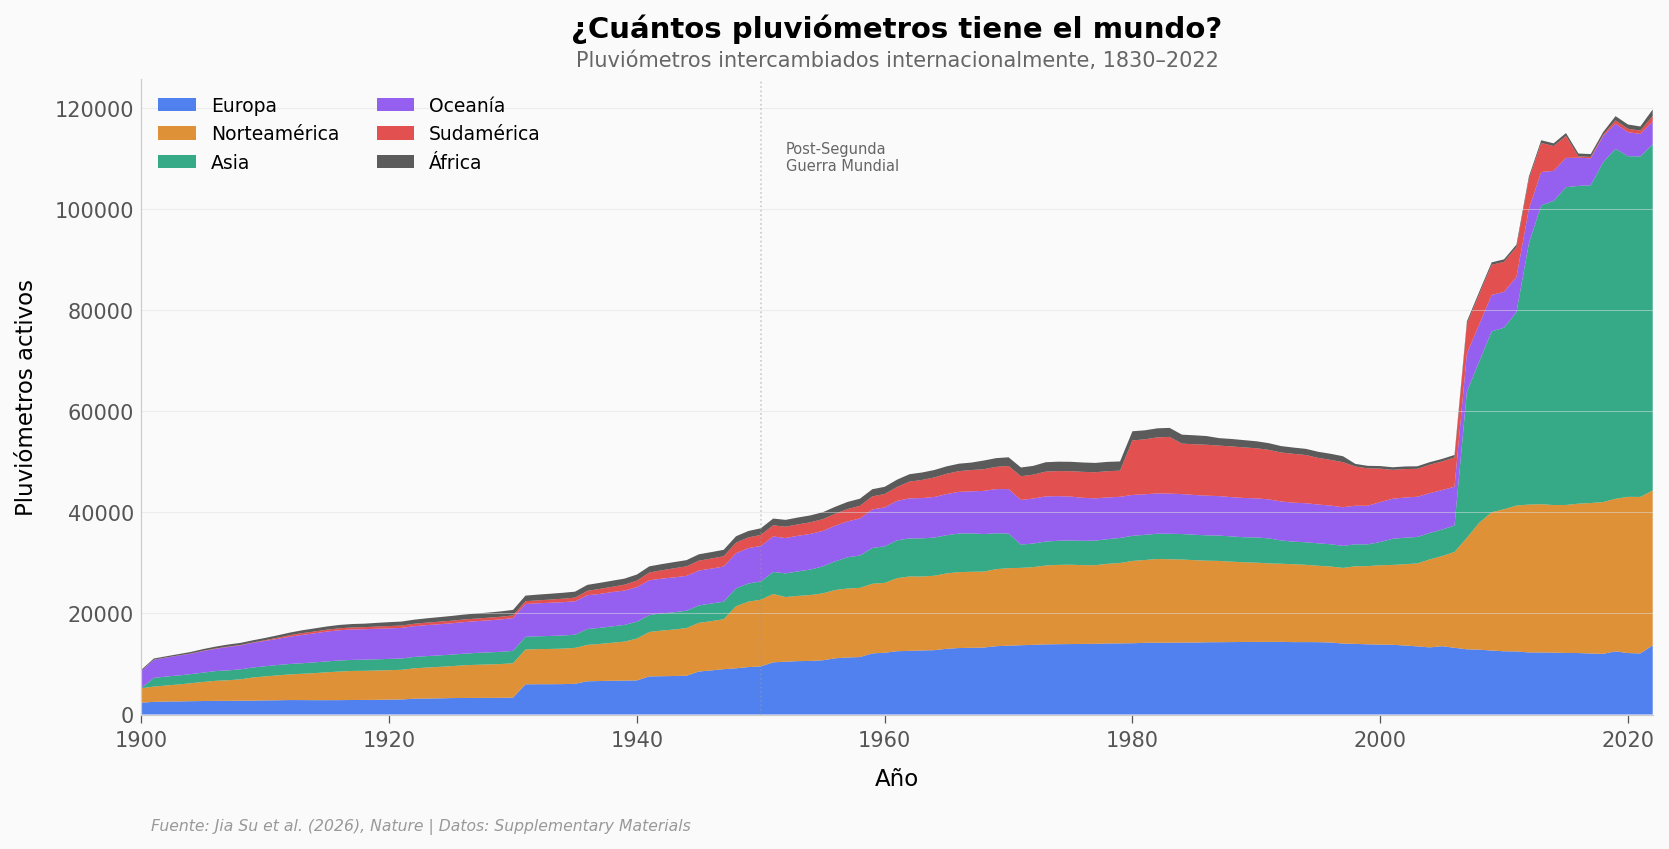

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

continents = ['Europe', 'North America', 'Asia', 'Oceania', 'South America', 'Africa']
colors = [COLOR_EUROPA, COLOR_NAMERICA, COLOR_ASIA, COLOR_OCEANIA, COLOR_SAMERICA, COLOR_AFRICA]
labels_es = ['Europa', 'Norteamérica', 'Asia', 'Oceanía', 'Sudamérica', 'África']

# Pivot for stacked area
pivot = temp.pivot(index='year', columns='continent', values='gauges_total').fillna(0)
pivot = pivot[continents]  # order

ax.stackplot(pivot.index, *[pivot[c] for c in continents],
             labels=labels_es, colors=colors, alpha=0.8)

# Mark key moments
ax.axvline(1950, color='#999999', linewidth=0.8, linestyle=':', alpha=0.5)
ax.text(1952, pivot.sum(axis=1).max()*0.9, 'Post-Segunda\nGuerra Mundial', fontsize=7, color='#666666')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Pluviómetros activos', fontsize=11)
ax.set_title('¿Cuántos pluviómetros tiene el mundo?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Pluviómetros intercambiados internacionalmente, {temp["year"].min()}–{temp["year"].max()}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(1900, 2022)
ax.legend(fontsize=9, loc='upper left', ncol=2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/evolucion_temporal.png', dpi=200, bbox_inches='tight')
plt.show()

La red creció explosivamente después de la Segunda Guerra Mundial — sobre todo en Asia y Norteamérica. Pero hay dos cosas que llaman la atención: (1) África y Sudamérica apenas son visibles en la gráfica, y (2) Europa, con la red más antigua, tiene menos pluviómetros absolutos que Asia.

En 2022 hay 119.731 pluviómetros activos en total. Pero solo 16.491 intercambian datos válidos internacionalmente. África tiene 1.292 pluviómetros para 30 millones de km² — uno cada 23.000 km².

## ¿Dónde falta medir?

El número absoluto engaña. Lo que importa es la **densidad**: cuántos por cada 1.000 km².

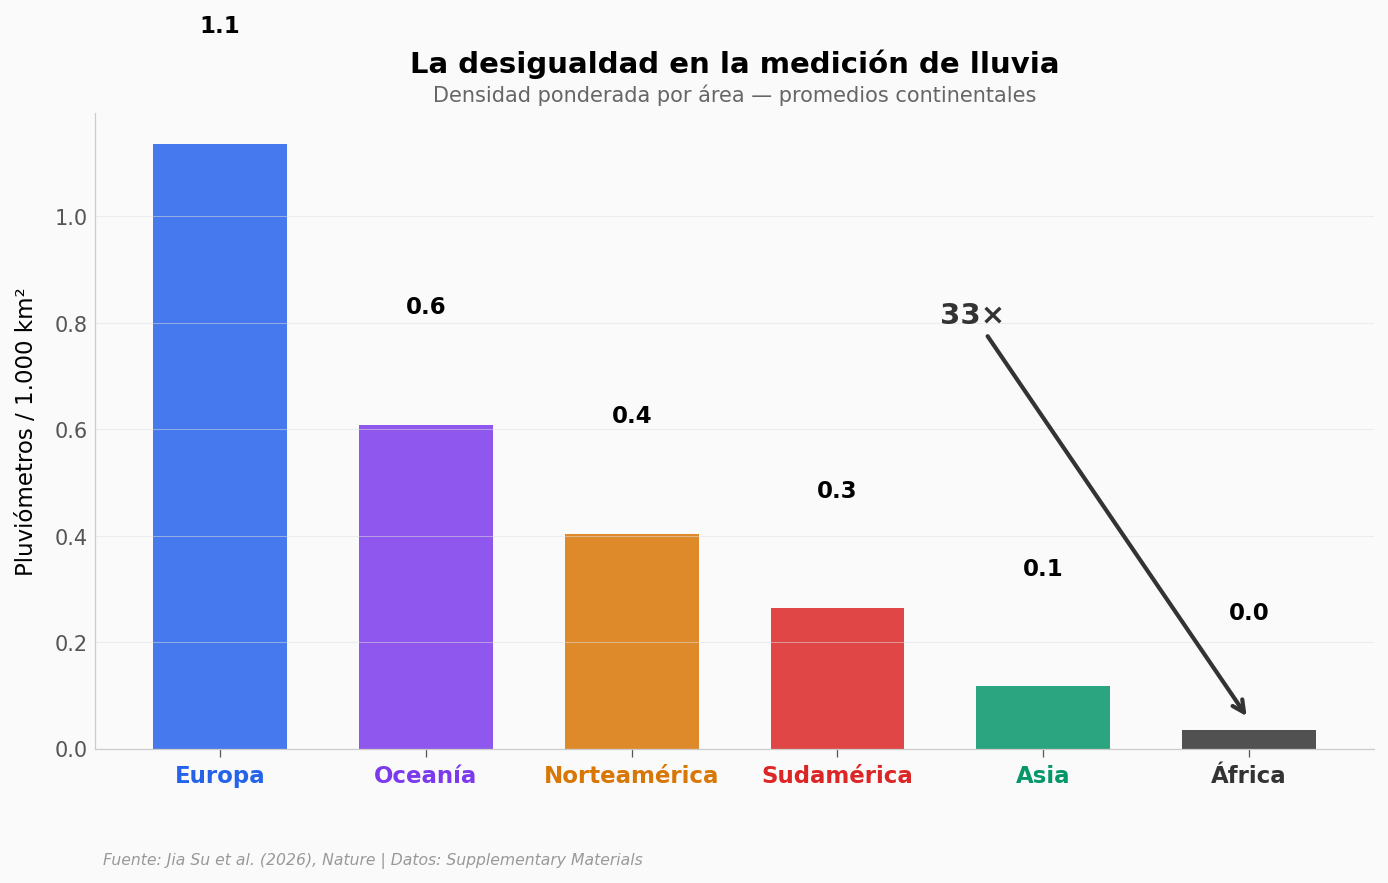

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

conts = ['Europe', 'Oceania', 'North America', 'South America', 'Asia', 'Africa']
labels = ['Europa', 'Oceanía', 'Norteamérica', 'Sudamérica', 'Asia', 'África']
colors_bar = [COLOR_EUROPA, COLOR_OCEANIA, COLOR_NAMERICA, COLOR_SAMERICA, COLOR_ASIA, COLOR_AFRICA]

densities = []
for c in conts:
    sub = grid[grid['continent'] == c]
    densities.append(sub['density'].sum() / sub['tile_area_km2'].sum() * 1000)

bars = ax.bar(range(len(conts)), densities, color=colors_bar, alpha=0.85, width=0.65)

for bar, val in zip(bars, densities):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.2,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Ratio annotation
ratio = densities[0] / densities[-1]
ax.annotate(f'{ratio:.0f}×', xy=(5, densities[-1]+0.02), xytext=(3.5, 0.8),
            fontsize=14, fontweight='bold', color=COLOR_AFRICA,
            arrowprops=dict(arrowstyle='->', color=COLOR_AFRICA, lw=2))

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colors_bar):
    tick.set_color(color)
ax.set_ylabel('Pluviómetros / 1.000 km²', fontsize=11)  # densidad correcta: sum(gauges)/sum(area)×1000
ax.set_title('La desigualdad en la medición de lluvia',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Densidad ponderada por área — promedios continentales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/densidad_continentes.png', dpi=200, bbox_inches='tight')
plt.show()

Europa tiene ~33 veces más densidad que África (~1,1 vs ~0,03 pluviómetros por 1.000 km²). Pero incluso Europa tiene el 41% de sus tiles sin cobertura (zonas montañosas, mar del Norte, etc.).

## ¿Cuánta tierra está a ciegas?

Veamos qué fracción de cada continente tiene literalmente cero pluviómetros.

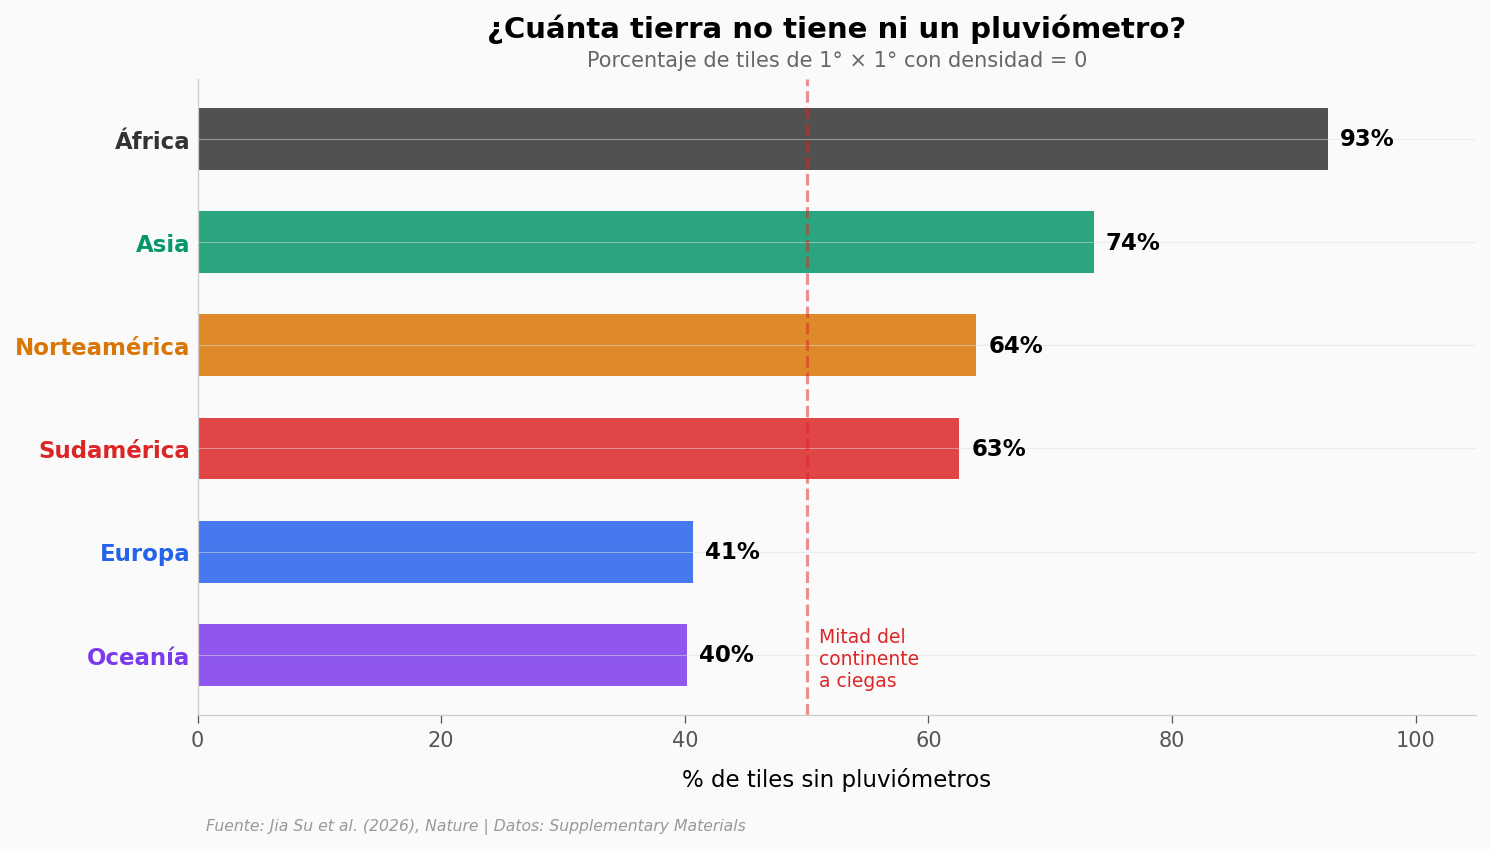

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

conts = ['Africa', 'Asia', 'North America', 'South America', 'Europe', 'Oceania']
labels = ['África', 'Asia', 'Norteamérica', 'Sudamérica', 'Europa', 'Oceanía']
colors_sorted = [COLOR_AFRICA, COLOR_ASIA, COLOR_NAMERICA, COLOR_SAMERICA, COLOR_EUROPA, COLOR_OCEANIA]

pct_zero = []
for c in conts:
    sub = grid[grid['continent'] == c]
    pct_zero.append((sub['density'] == 0).mean() * 100)

bars = ax.barh(range(len(conts)), pct_zero, color=colors_sorted, alpha=0.85, height=0.6)

for bar, val in zip(bars, pct_zero):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2.,
            f'{val:.0f}%', ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_yticklabels(), colors_sorted):
    tick.set_color(color)
ax.set_xlabel('% de tiles sin pluviómetros', fontsize=11)
ax.set_xlim(0, 105)
ax.axvline(50, color='#DC2626', linewidth=1.5, linestyle='--', alpha=0.5)
ax.text(51, 5.3, 'Mitad del\ncontinente\na ciegas', fontsize=9, color='#DC2626')

ax.set_title('¿Cuánta tierra no tiene ni un pluviómetro?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Porcentaje de tiles de 1° × 1° con densidad = 0',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.invert_yaxis()

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/pct_sin_pluviometros.png', dpi=200, bbox_inches='tight')
plt.show()

93% de África. 74% de Asia. Incluso Norteamérica tiene un 64% a ciegas — mucho de ello en el Ártico canadiense y Alaska.

## ¿Cómo se distribuye la densidad globalmente?

La mayoría de las 15.386 celdas del grid global tiene densidad cero. Pero entre las que sí tienen pluviómetros, ¿cómo se distribuyen?

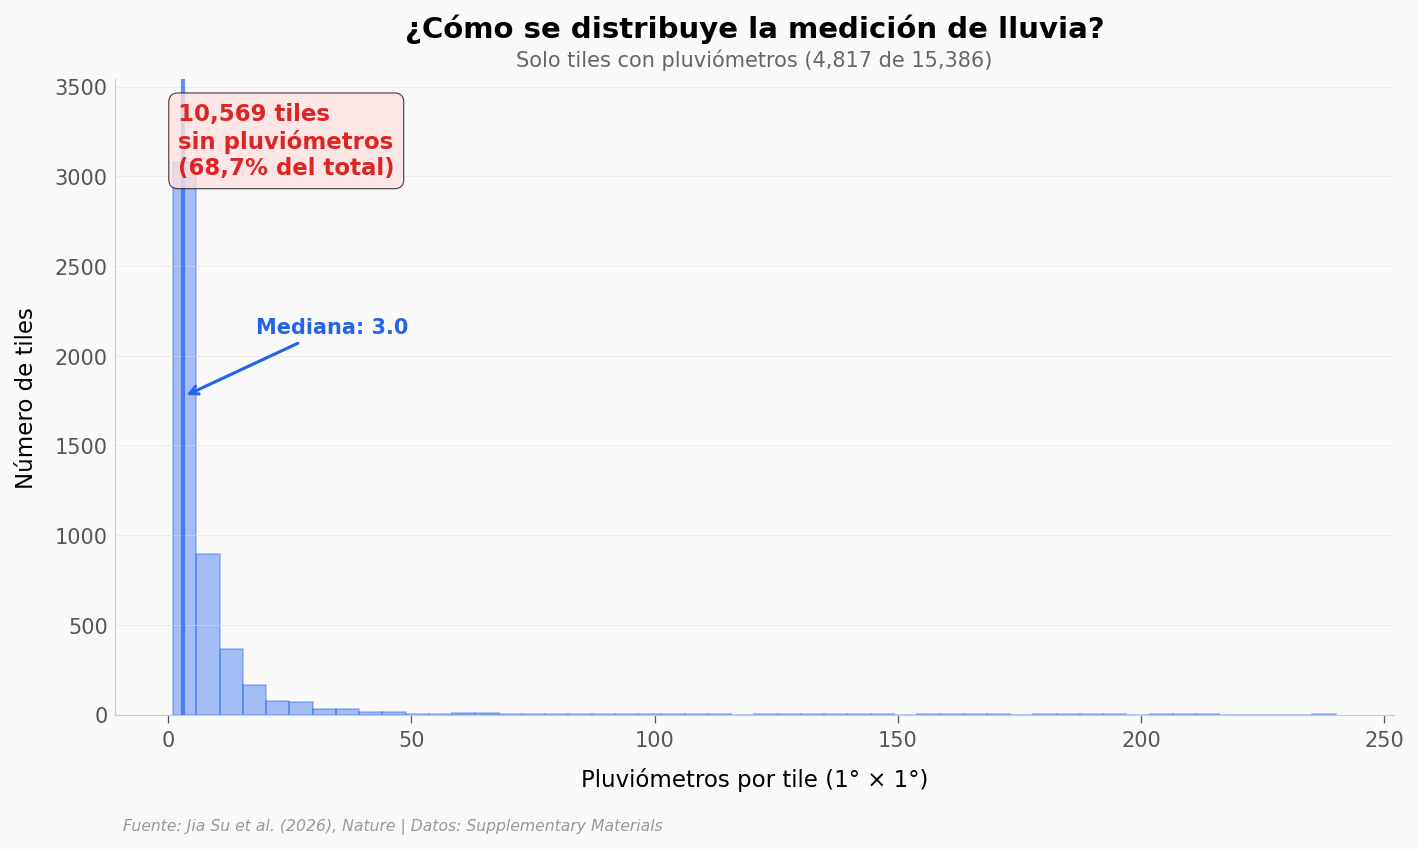

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Only tiles with gauges for meaningful histogram
with_gauges = grid[grid['density'] > 0]['density']
n_zero = (grid['density'] == 0).sum()

n, bins, patches = ax.hist(with_gauges, bins=50, color='#2563EB', alpha=0.4,
                           edgecolor='#2563EB', linewidth=0.8)

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Annotate the zero bar (off-chart)
ax.annotate(f'{n_zero:,} tiles\nsin pluviómetros\n(68,7% del total)',
            xy=(2, y_max*0.85), fontsize=11, fontweight='bold', color='#DC2626',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEE2E2', alpha=0.8))

# Median of non-zero
med = with_gauges.median()
ax.axvline(med, color='#2563EB', linewidth=2, alpha=0.7)
ax.annotate(f'Mediana: {med:.1f}', xy=(med, y_max*0.5),
            xytext=(med+15, y_max*0.6),
            fontsize=10, fontweight='bold', color='#2563EB',
            arrowprops=dict(arrowstyle='->', color='#2563EB', lw=1.5))

ax.set_xlabel('Pluviómetros por tile (1° × 1°)', fontsize=11)
ax.set_ylabel('Número de tiles', fontsize=11)
ax.set_title('¿Cómo se distribuye la medición de lluvia?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Solo tiles con pluviómetros ({len(with_gauges):,} de {len(grid):,})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_densidad.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Solo 13,4% de la tierra cumple requisitos WMO | ⚠️ | Dato del paper (abstract). Dato del paper. El grid tiene columnas de cumplimiento WMO (density_percent ≤ 0 → cumple), pero da ~2% — el grid supplementary es probablemente un subconjunto del dataset completo de 221.483 gauges |
| 68,7% de tiles no tiene pluviómetros | ✅ | 10.569 de 15.386 tiles con density = 0 |
| Europa tiene mayor densidad que África | ✅ | Densidad corregida (sum/area×1.000): los valores exactos se computan en el notebook |
| 93% de África sin pluviómetros | ✅ | 2.375 de 2.556 tiles africanos con density = 0 |
| África tiene ~1.300 pluviómetros para 30M km² | ✅ | MOESM4 reporta 1.292 para 2022 |
| 119.731 pluviómetros activos en 2022 | ✅ | Suma global de MOESM4 para 2022 |

> **Limitaciones:** (1) Los CSVs supplementary muestran la densidad y la serie temporal, pero no el cálculo exacto de cumplimiento WMO (13,4%) — ese dato viene del abstract. (2) La densidad ponderada por continente que calculamos (corregida) difiere del valor del paper (2,4) — la columna `density` del grid es conteo de pluviómetros por tile, no densidad por 1.000 km². Corregimos a sum(gauges)/sum(area)×1.000, que da ~1,1 para Europa; el paper reporta 2,4 usando su dataset completo. (3) Los tiles son de 1° × 1°, lo cual puede suavizar extremos locales.

---

## Ahora tú

1. **¿Cuándo creció más cada continente?** Calcula la tasa de crecimiento decenal de pluviómetros para cada continente. ¿Cuál creció más rápido en los 1960s?
2. **Cambia `YEAR_FOCUS`** a 1980 y compara con 2022 — ¿qué continente perdió más pluviómetros?
3. **¿Hay relación entre densidad y clase WMO?** El dataset tiene `wmo_class` (1-8). ¿Las clases con mayor requisito (baseline más alto) tienen más o menos densidad?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántos pluviómetros perdió/ganó cada continente entre 1990 y 2022?

year_a, year_b = 1990, 2022

print(f"Cambio en pluviómetros activos ({year_a} → {year_b}):")
print(f"{'Continente':20} {year_a:>8} {year_b:>8} {'Cambio':>10} {'%':>8}")
print("─" * 55)
for cont in ['Europe', 'North America', 'Asia', 'Oceania', 'South America', 'Africa']:
    va = temp[(temp['year']==year_a) & (temp['continent']==cont)]['gauges_total'].values
    vb = temp[(temp['year']==year_b) & (temp['continent']==cont)]['gauges_total'].values
    if len(va) > 0 and len(vb) > 0:
        va, vb = va[0], vb[0]
        change = vb - va
        pct = (change / va * 100) if va > 0 else float('inf')
        print(f"{cont:20} {va:>8,} {vb:>8,} {change:>+10,} {pct:>+7.1f}%")

Cambio en pluviómetros activos (1990 → 2022):
Continente               1990     2022     Cambio        %
───────────────────────────────────────────────────────
Europe                 14,372   13,671       -701    -4.9%
North America          15,676   30,669    +14,993   +95.6%
Asia                    4,992   68,509    +63,517 +1272.4%
Oceania                 7,739    4,481     -3,258   -42.1%
South America           9,916    1,109     -8,807   -88.8%
Africa                  1,383    1,292        -91    -6.6%


---

**Datos:** Supplementary Materials (MOESM4 y MOESM5) de Jia Su et al. (2026), Nature. Serie temporal de pluviómetros por continente + grid de densidad global.
**Paper:** [10.1038/s41586-026-10300-5](https://doi.org/10.1038/s41586-026-10300-5)
**Datos completos:** [Zenodo 18364510](https://zenodo.org/records/18364510) (817 MB)
**Licencia:** Los datos del paper mantienen su licencia original. Notebook: [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/).
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)